###Preparación del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline


Aqui fijamos una semilla para reproducir los resultados

In [2]:
np.random.seed(3435)

###cargue de datos

In [3]:
creditotrain = pd.read_excel("creditotrain.xlsx")
creditotest  = pd.read_excel("creditotest.xlsx")



In [4]:
print("Dimensiones train:", creditotrain.shape)
print("Columnas train:", creditotrain.columns.tolist())
print(creditotrain.info())


Dimensiones train: (439, 5)
Columnas train: ['tiempo', 'vendedor', 'tipo_cliente', 'condicion', 'resultado']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   tiempo        439 non-null    object
 1   vendedor      439 non-null    object
 2   tipo_cliente  439 non-null    object
 3   condicion     439 non-null    object
 4   resultado     439 non-null    object
dtypes: object(5)
memory usage: 17.3+ KB
None


Aqui volvemos las columnas categóricas.

In [5]:
cat_cols = creditotrain.columns[:5].tolist()  # primeras 5 columnas como categóricas
for c in cat_cols:
    creditotrain[c] = creditotrain[c].astype("category")
    # Intentamos forzar categorías consistentes también en test
    creditotest[c] = pd.Categorical(creditotest[c], categories=creditotrain[c].cat.categories)


Separamos predictores de variable a predecir y codificamos las clases de la variable a predecir.

In [6]:
target = "resultado"

X_train = creditotrain.drop(columns=[target])
y_train = creditotrain[target].astype("category")  # aseguramos categórica

X_test = creditotest.drop(columns=[target])
y_test = creditotest[target].astype("category")

# Codificar y (clases) con LabelEncoder para modelos de sklearn
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

class_names = le.classes_.tolist()
print("Clases en 'resultado':", class_names)


Clases en 'resultado': ['Exitoso', 'Fallido', 'Parcial']


Preparamos las variables predictoras como unos y ceros

In [7]:
# asegurar que 'resultado' no está en las variables x
cat_cols_for_processing = [c for c in cat_cols if c != target]

# Compatibilidad con versiones de sklearn (sparse_output vs sparse)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols_for_processing)
        # no hay numéricas
    ]
)

# Ajuste y transformación
X_train_enc = preprocess.fit_transform(X_train)
X_test_enc  = preprocess.transform(X_test)

In [8]:
try:
    ohe_feature_names = preprocess.named_transformers_["cat"].get_feature_names_out(cat_cols_for_processing).tolist()
except AttributeError:
    # fallback para versiones antiguas
    ohe_feature_names = preprocess.named_transformers_["cat"].get_feature_names(cat_cols_for_processing).tolist()

feature_names = ohe_feature_names # num_cols is not defined, removed it

print("Dimensiones después de OHE:", X_train_enc.shape)

Dimensiones después de OHE: (439, 10)


###Ejecución de árboles

In [9]:
arbol = DecisionTreeClassifier(
    random_state=3435,  # equivalente a set.seed
    criterion="gini"    # rpart por defecto usa una variante de Gini para clasificación
)
arbol.fit(X_train_enc, y_train_enc)


DecisionTreeClassifier(random_state=3435)

In [10]:
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.5
})


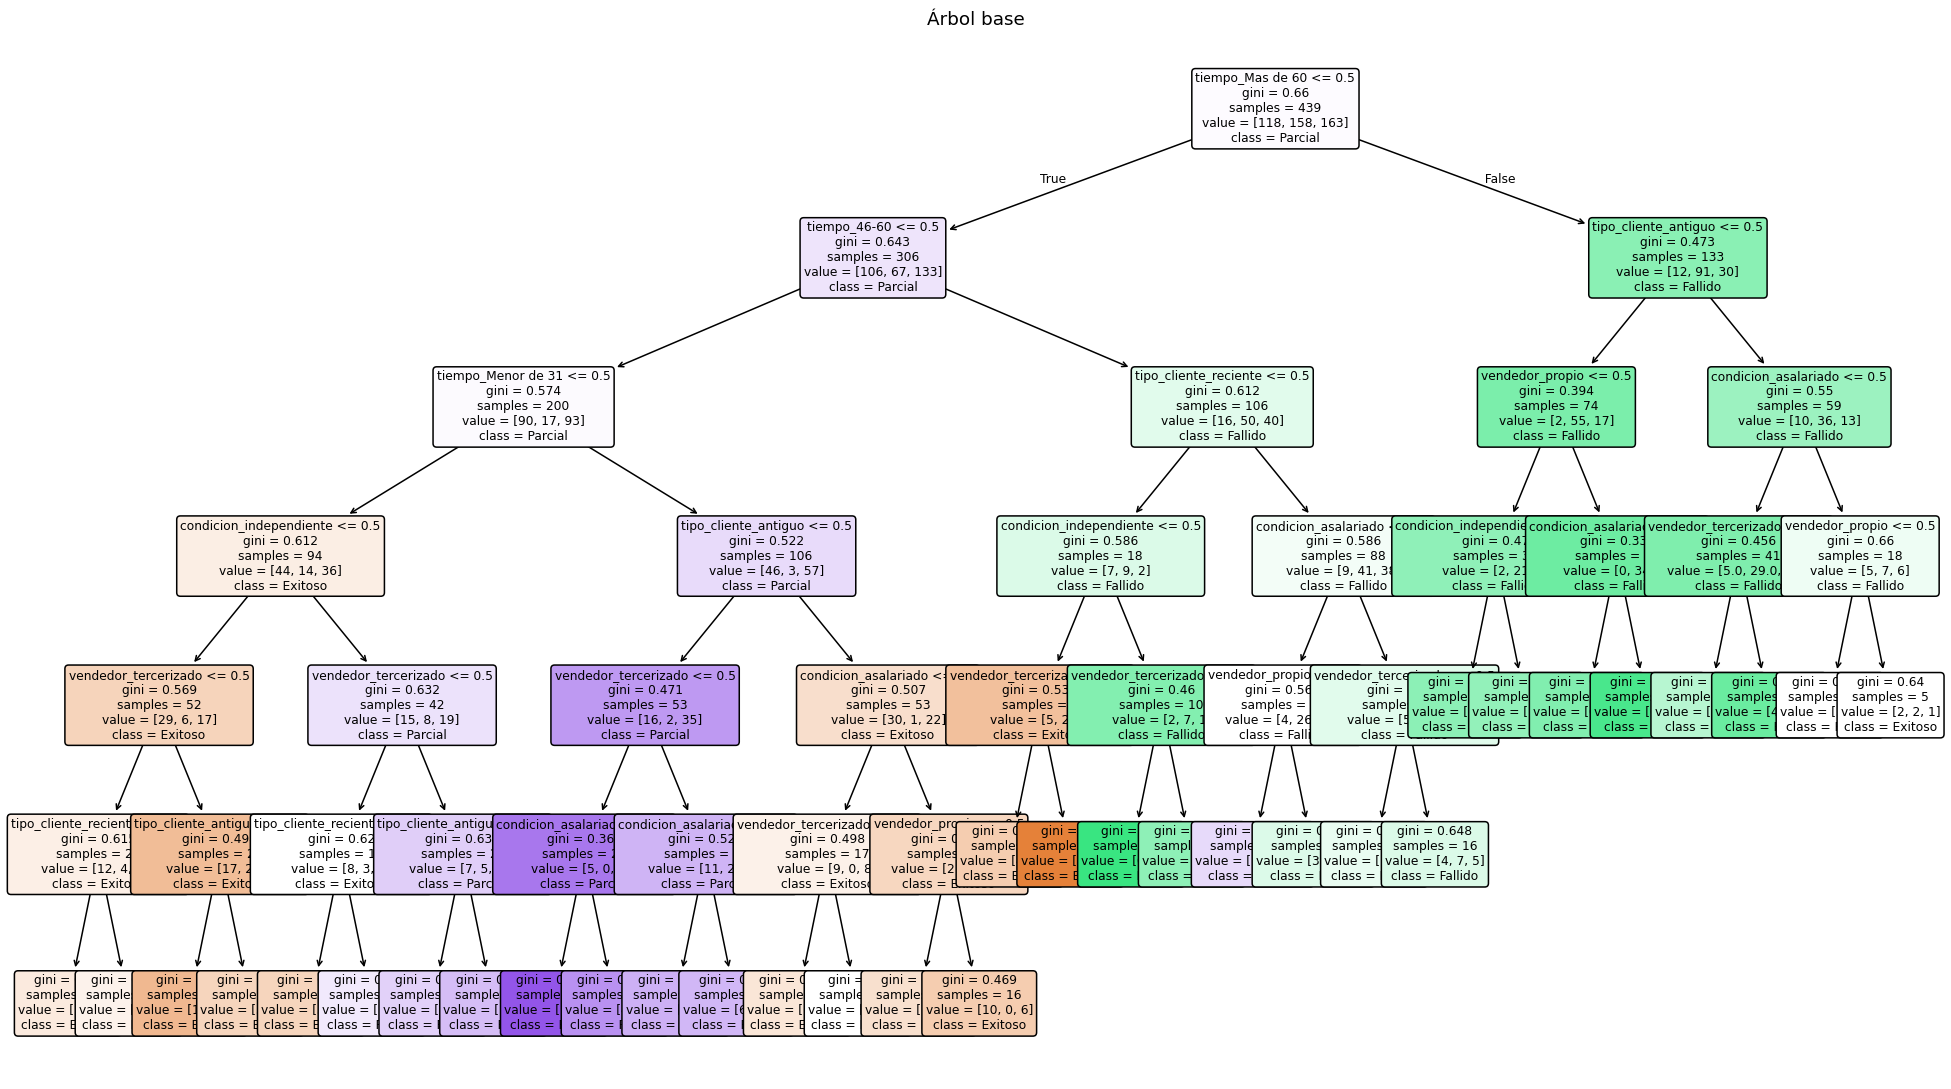

In [11]:
plt.figure(figsize=(18, 10))
plot_tree(
    arbol,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol base ")
plt.tight_layout()
plt.show()


Miramos cambios en los resultados del modelo

In [12]:
path = arbol.cost_complexity_pruning_path(X_train_enc, y_train_enc)
ccp_alphas, impurities = path.ccp_alphas, path.impurities



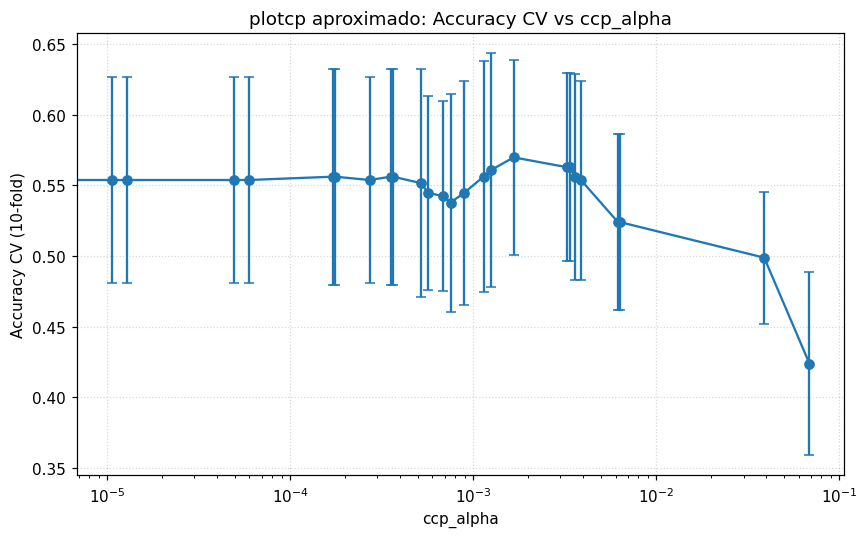

In [13]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=3435)
mean_scores = []
std_scores = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=3435, ccp_alpha=alpha)
    scores = cross_val_score(clf, X_train_enc, y_train_enc, cv=cv)
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())

plt.figure(figsize=(8, 5))
plt.errorbar(ccp_alphas, mean_scores, yerr=std_scores, marker="o", capsize=3)
plt.xscale("log")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy CV (10-fold)")
plt.title("plotcp aproximado: Accuracy CV vs ccp_alpha")
plt.tight_layout()
plt.show()



In [14]:
# Tabla tipo 'printcp'
cp_table = pd.DataFrame({
    "ccp_alpha": ccp_alphas,
    "media": mean_scores
})
print("\n=== Tabla de precisiones a niveles de ccp_alpha")
display(cp_table)



=== Tabla de precisiones a niveles de ccp_alpha


,ccp_alpha,media
0,0.000000,0.553753
1,0.000011,0.553753
2,0.000013,0.553753
3,0.000050,0.553753
4,0.000060,0.553753
5,0.000171,0.556078
6,0.000177,0.556078
7,0.000272,0.553753
8,0.000354,0.556078
9,0.000365,0.556078


A partir de ello, escogemos parámetros de poda si lo deseamos

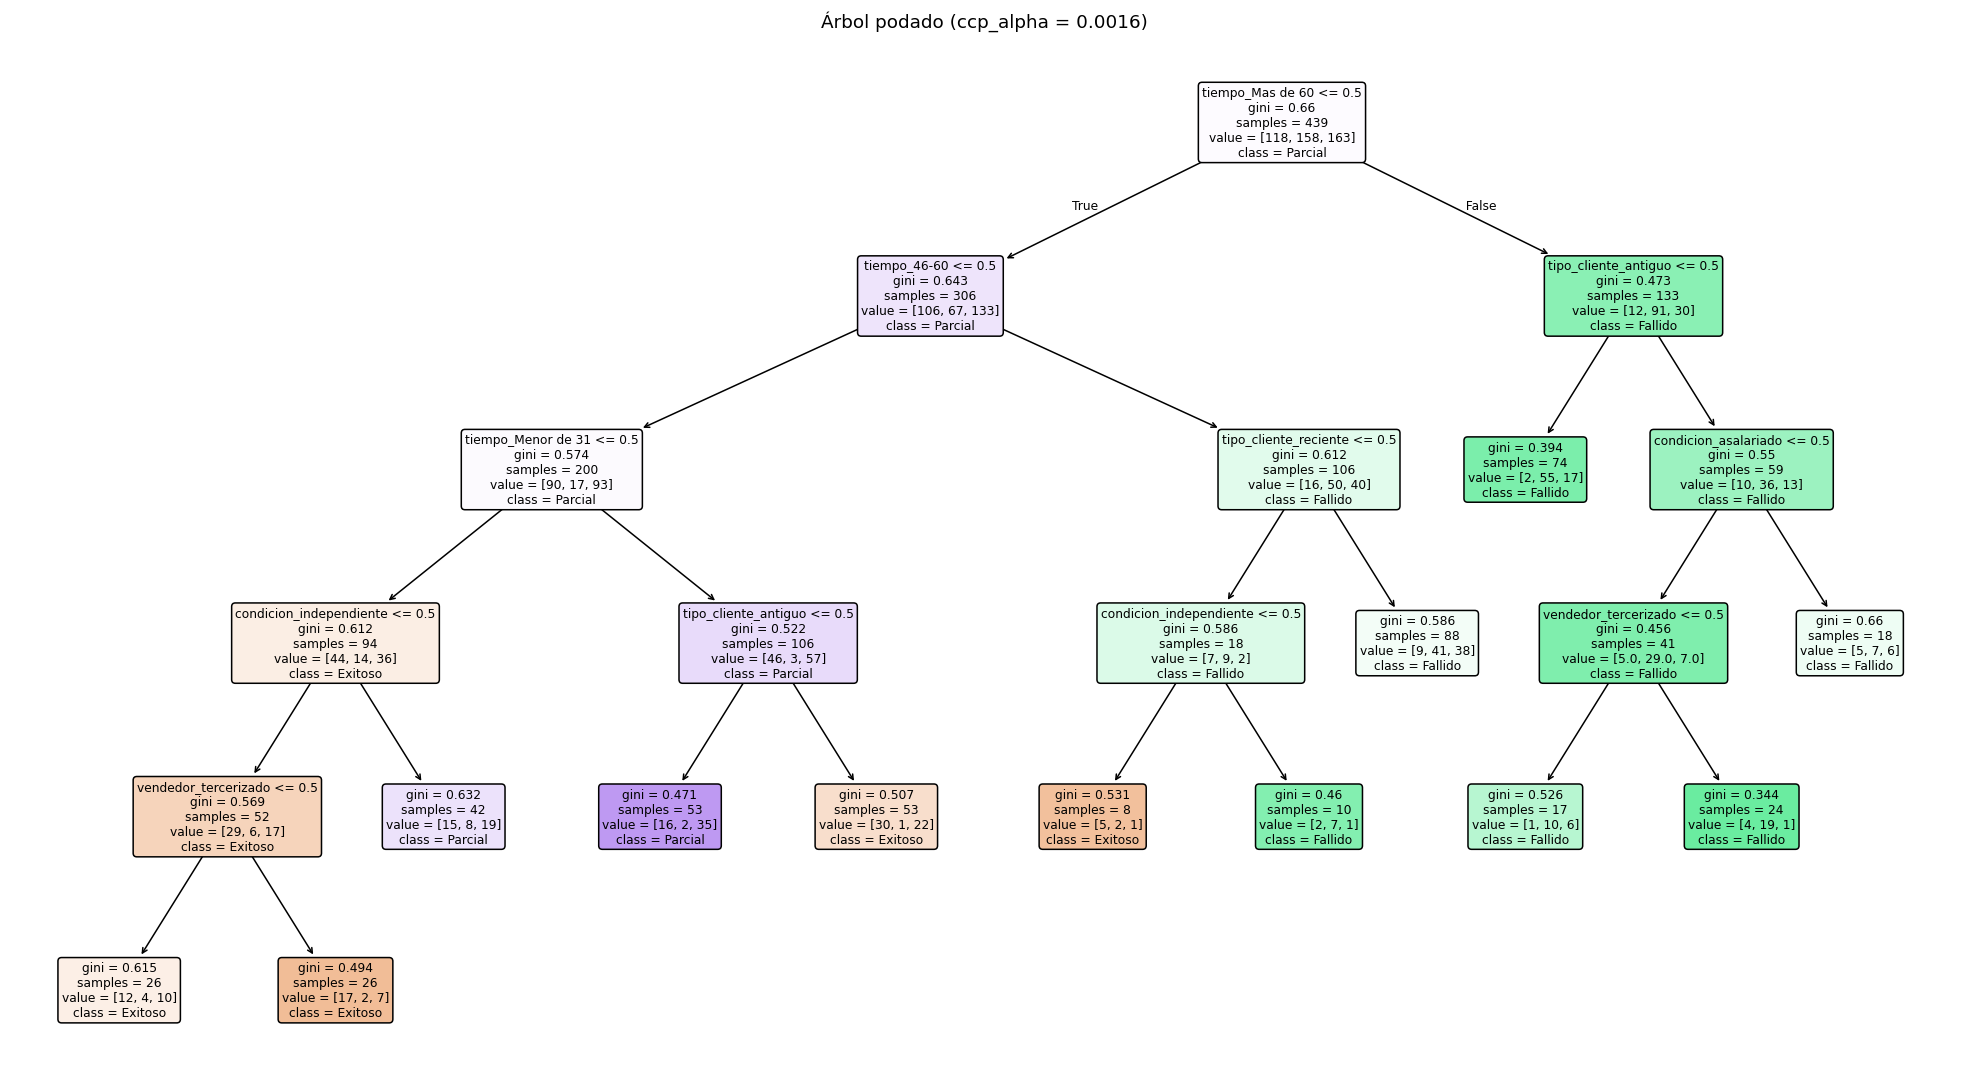

In [15]:
arbolPodado = DecisionTreeClassifier(random_state=3435, ccp_alpha=0.0016)
arbolPodado.fit(X_train_enc, y_train_enc)

plt.figure(figsize=(18, 10))
plot_tree(
    arbolPodado,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol podado (ccp_alpha = 0.0016)")
plt.tight_layout()
plt.show()



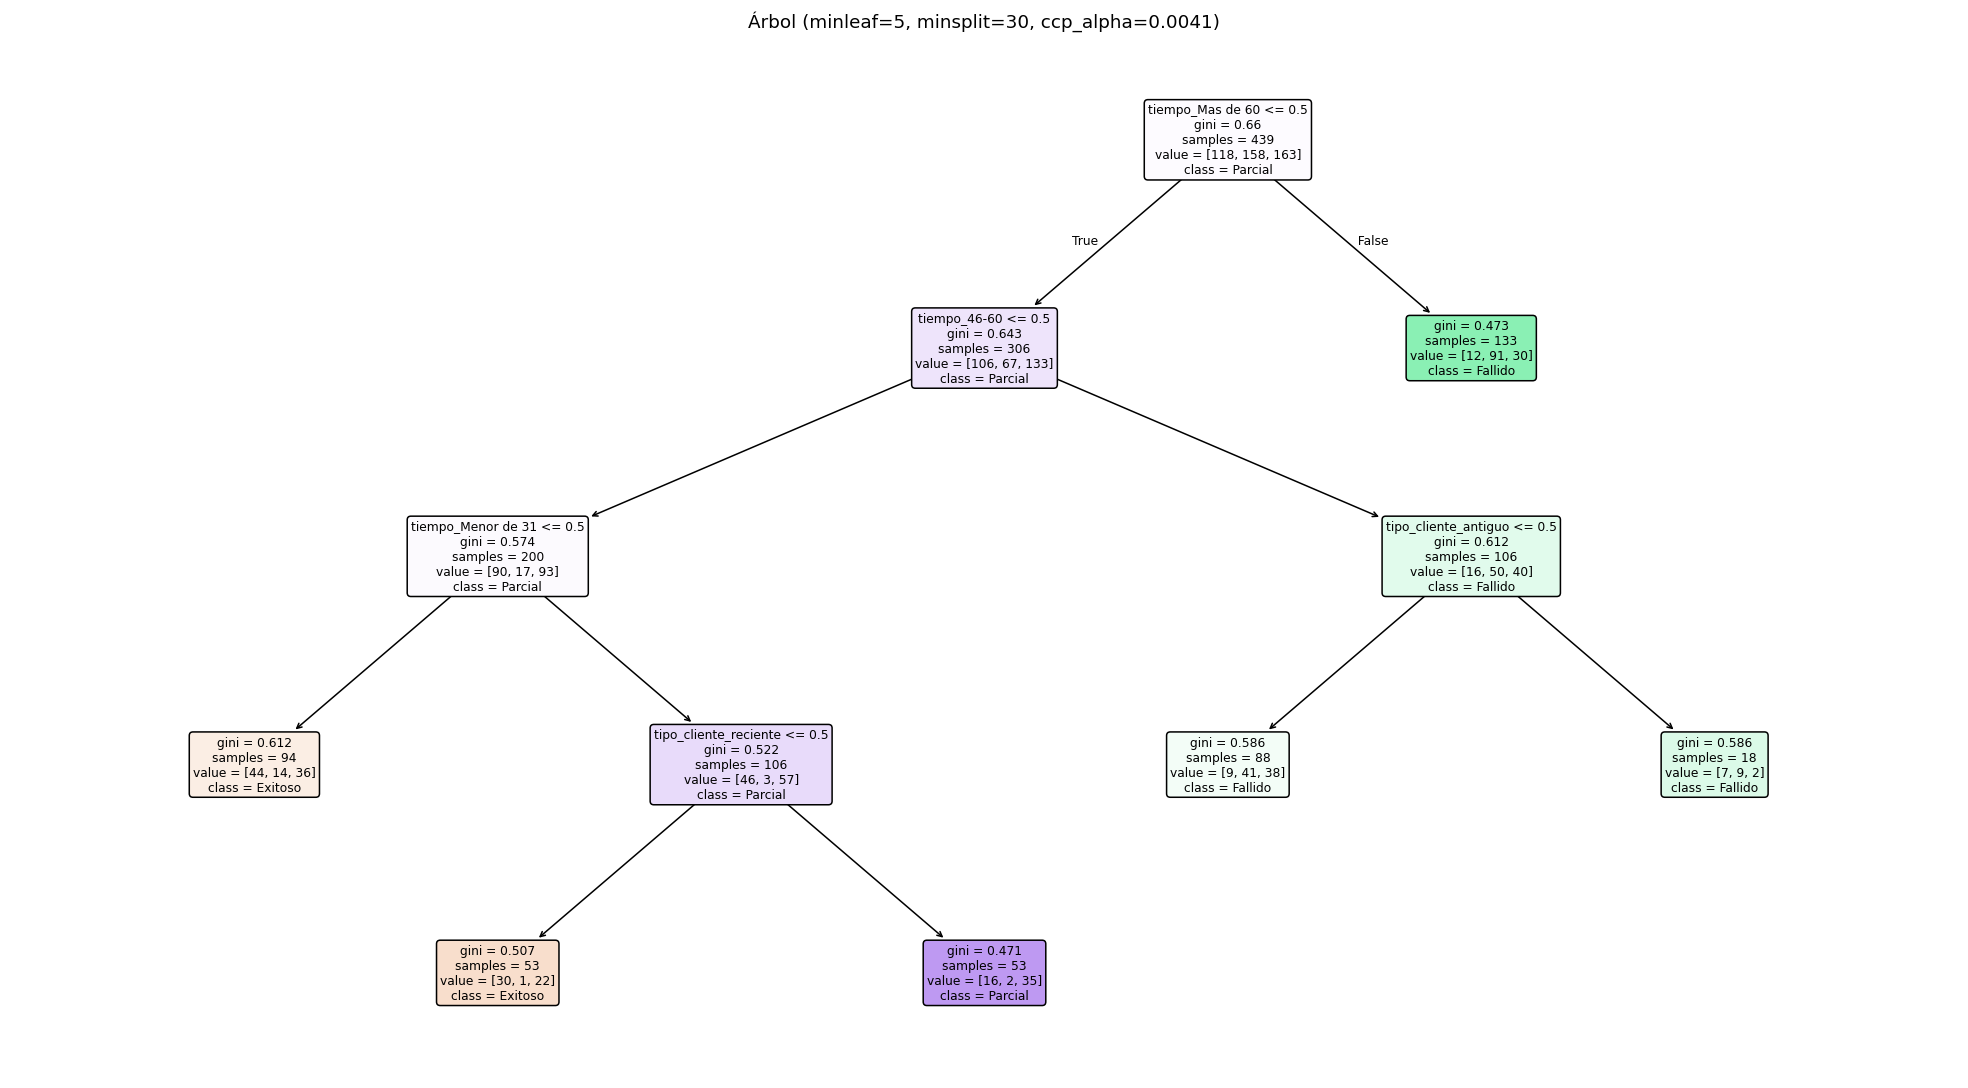

In [16]:
arbolnew = DecisionTreeClassifier(
    random_state=3435,
    min_samples_leaf=5,
    min_samples_split=30,
    ccp_alpha=0.0041
)
arbolnew.fit(X_train_enc, y_train_enc)

plt.figure(figsize=(18, 10))
plot_tree(
    arbolnew,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol (minleaf=5, minsplit=30, ccp_alpha=0.0041)")
plt.tight_layout()
plt.show()


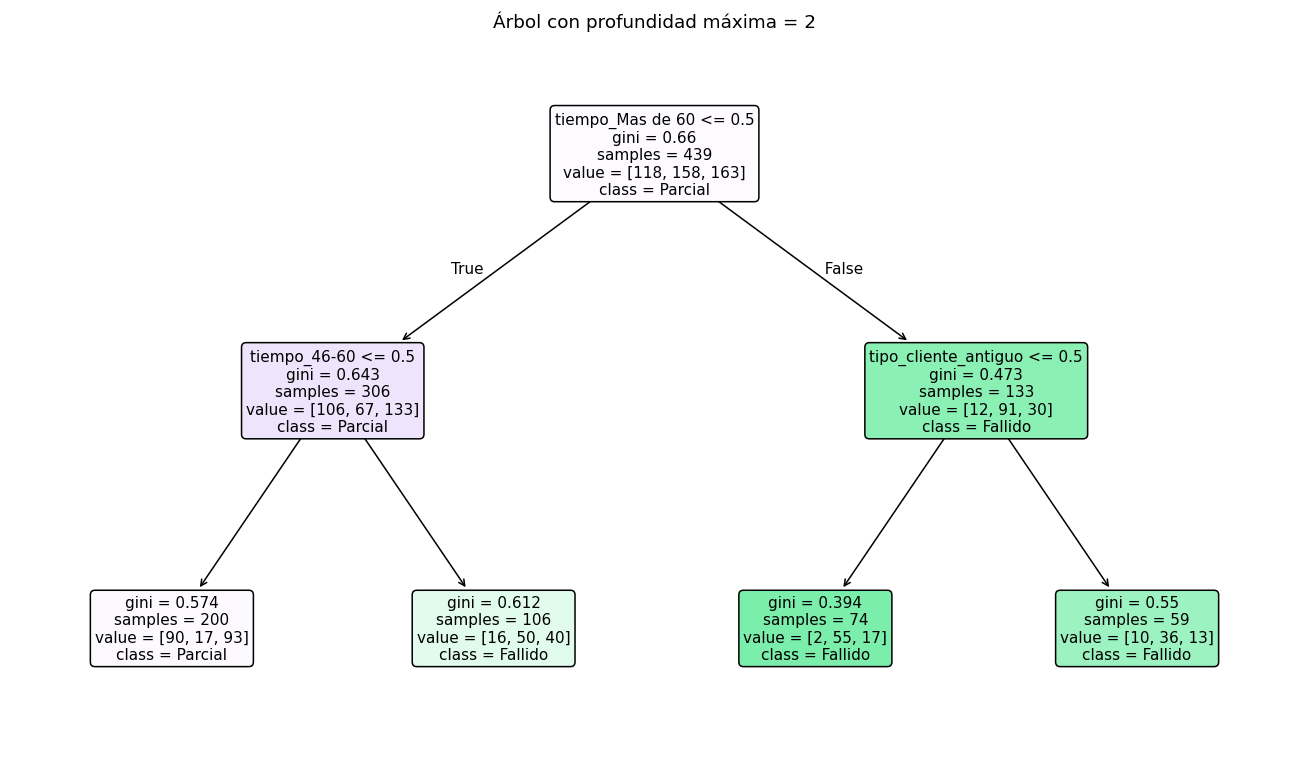

In [17]:
arbolnew2 = DecisionTreeClassifier(
    random_state=3435,
    max_depth=2
)
arbolnew2.fit(X_train_enc, y_train_enc)

plt.figure(figsize=(12, 7))
plot_tree(
    arbolnew2,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol con profundidad máxima = 2")
plt.tight_layout()
plt.show()



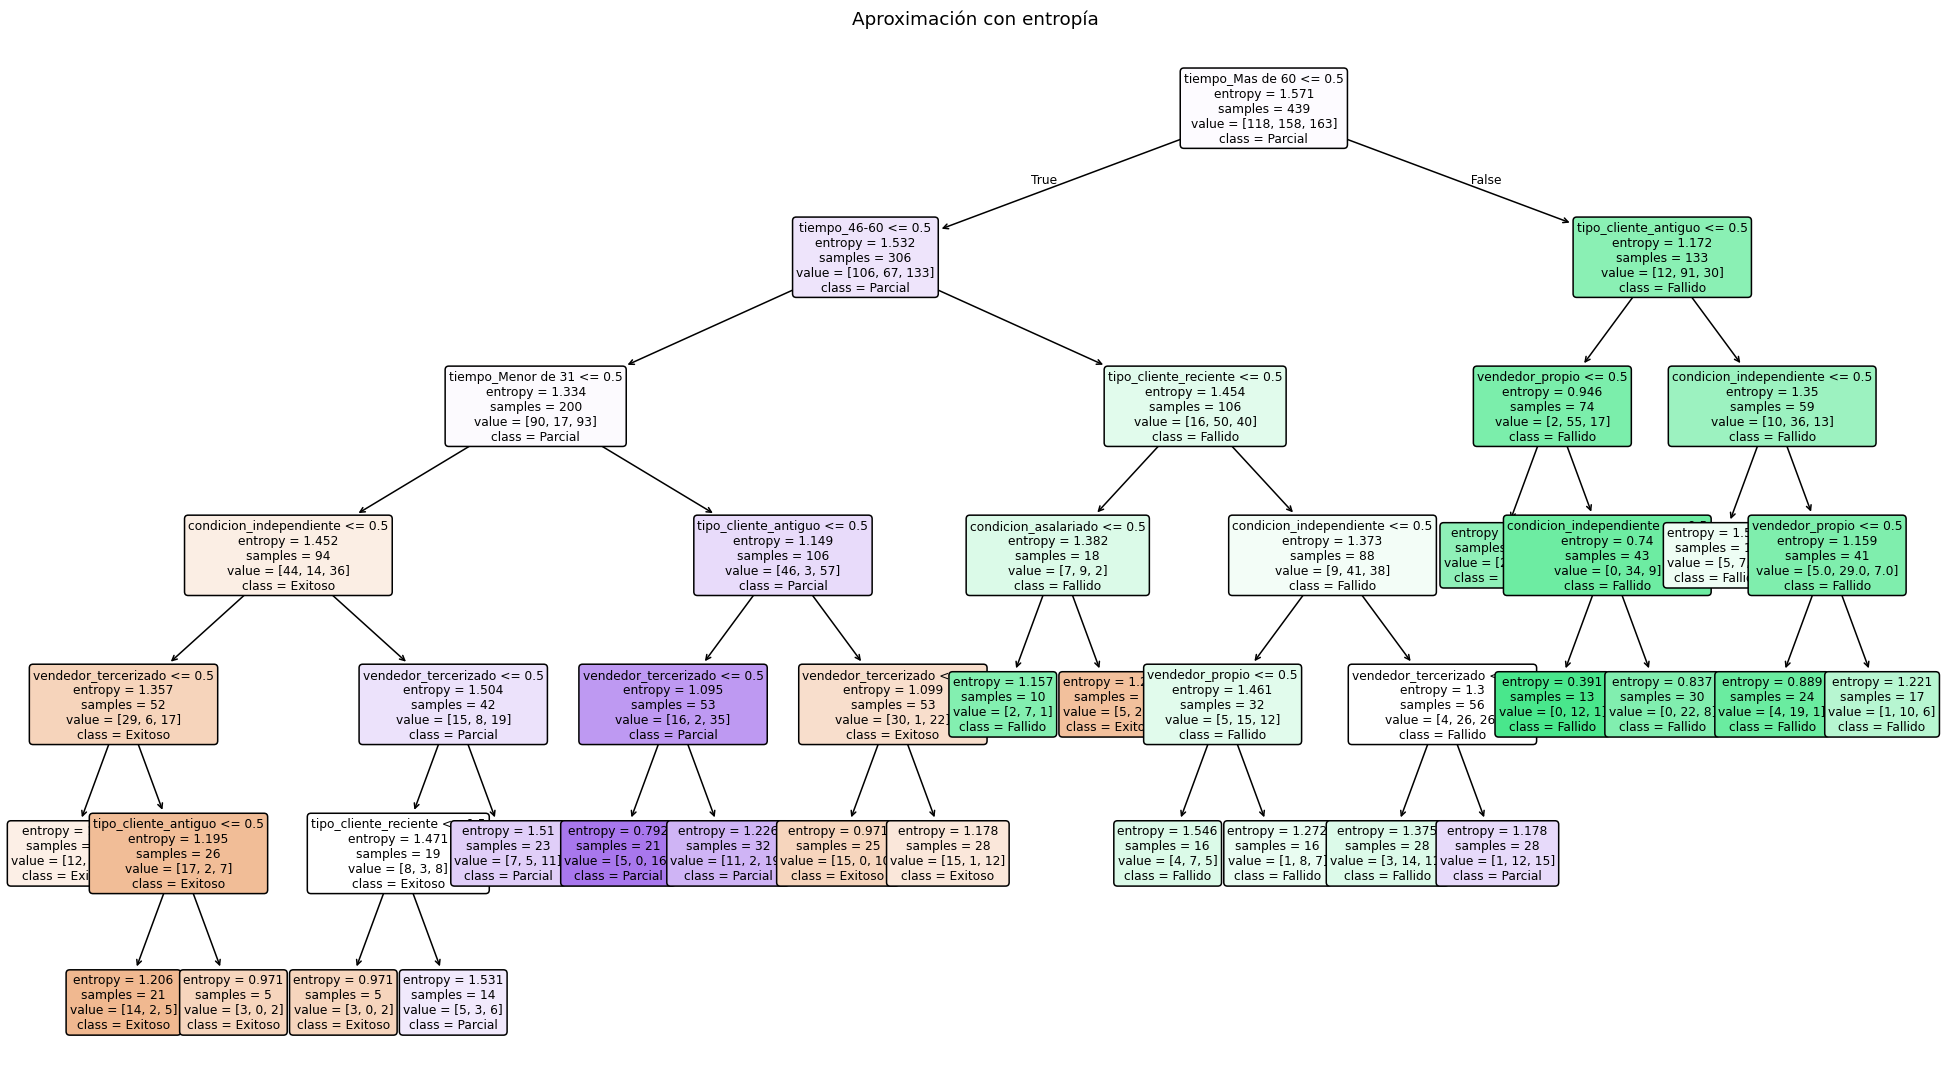

In [18]:
arbre = DecisionTreeClassifier(
    random_state=3435,
    criterion="entropy",
    ccp_alpha=0.002
)
arbre.fit(X_train_enc, y_train_enc)

plt.figure(figsize=(18, 10))
plot_tree(
    arbre,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Aproximación con entropía")
plt.tight_layout()
plt.show()



###Evaluaciones de modelos

In [19]:
pr   = le.inverse_transform(arbol.predict(X_test_enc))
pr1  = le.inverse_transform(arbolPodado.predict(X_test_enc))
pr2  = le.inverse_transform(arbolnew.predict(X_test_enc))
pr3  = le.inverse_transform(arbolnew2.predict(X_test_enc))
prch = le.inverse_transform(arbre.predict(X_test_enc))  # 'ctree' aproximado

# Probabilidades del árbol base (equiv. a type="prob")
pr1a_proba = arbol.predict_proba(X_test_enc)
pr1a = pd.DataFrame(pr1a_proba, columns=[f"prob_{c}" for c in class_names])
print("\nPrimeras filas de probabilidades del árbol base:")
display(pr1a.head())



Primeras filas de probabilidades del árbol base:


,prob_Exitoso,prob_Fallido,prob_Parcial
0,0.066667,0.666667,0.266667
1,0.066667,0.666667,0.266667
2,0.600000,0.000000,0.400000
3,0.000000,0.733333,0.266667
4,0.000000,0.733333,0.266667


In [20]:
def evaluar_modelo(y_true, y_pred, titulo=""):
    """Imprime matriz de confusión y F1 por clase. Grafica confusión."""
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(5.8, 5))
    disp.plot(ax=ax, values_format='d', cmap="Blues", colorbar=False)
    plt.title(f"Matriz de confusión - {titulo}")
    plt.tight_layout()
    plt.show()

    # F1 por clase (en el orden de class_names)
    f1s = f1_score(y_true, y_pred, average=None, labels=class_names)
    f1_series = pd.Series(f1s, index=class_names, name="F1")
    print(f"F1 por clase - {titulo}")
    display(f1_series)

y_true_labels = y_test.astype(str).values  # mantener etiquetas originales


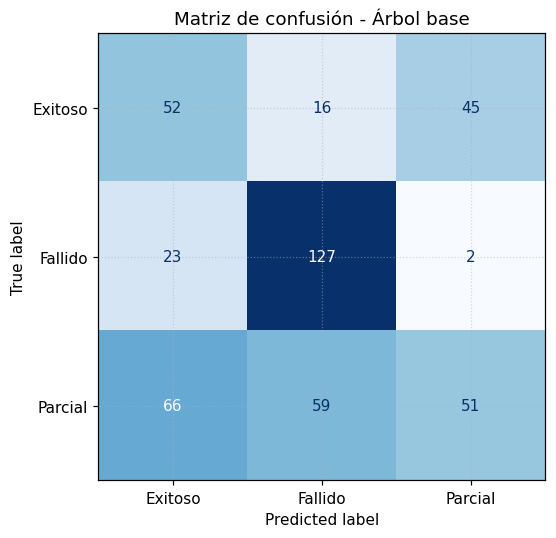

F1 por clase - Árbol base


,F1
Exitoso,0.409449
Fallido,0.717514
Parcial,0.372263


In [21]:
evaluar_modelo(y_true_labels, pr,  "Árbol base")



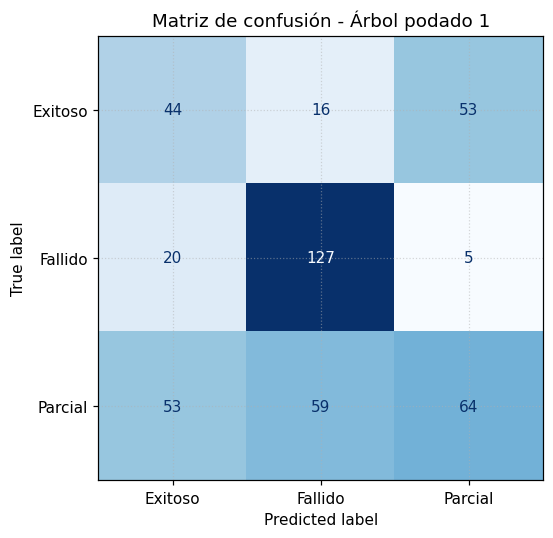

F1 por clase - Árbol podado 1


,F1
Exitoso,0.382609
Fallido,0.717514
Parcial,0.429530


In [22]:
evaluar_modelo(y_true_labels, pr1, "Árbol podado 1")


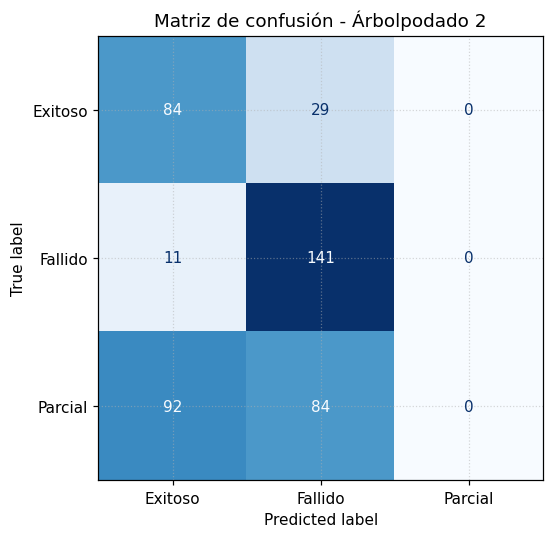

F1 por clase - Árbolpodado 2


,F1
Exitoso,0.560000
Fallido,0.694581
Parcial,0.000000


In [23]:
evaluar_modelo(y_true_labels, pr2, "Árbolpodado 2")


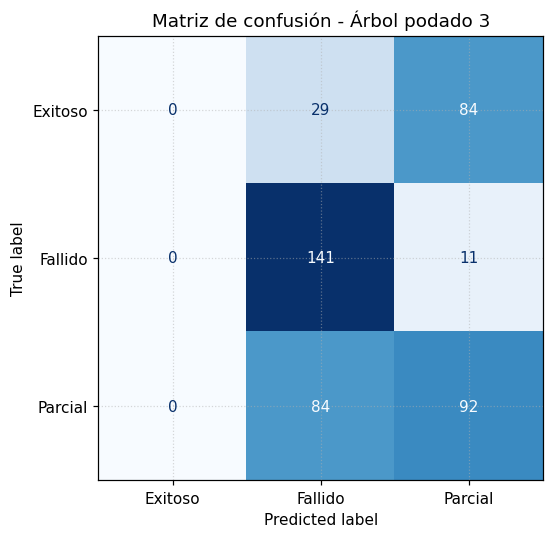

F1 por clase - Árbol podado 3


,F1
Exitoso,0.000000
Fallido,0.694581
Parcial,0.506887


In [24]:
evaluar_modelo(y_true_labels, pr3, "Árbol podado 3")


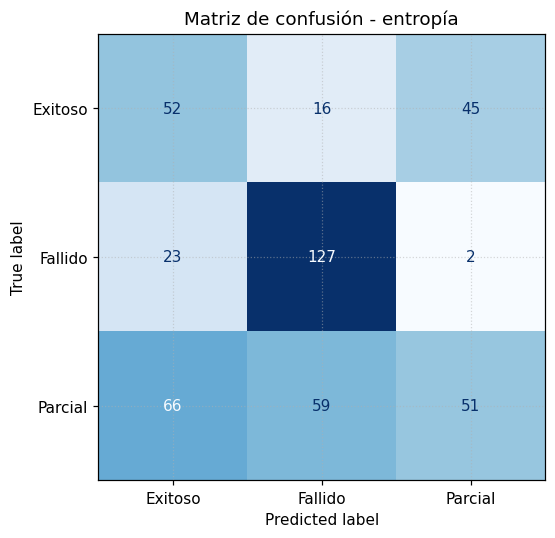

F1 por clase - entropía


,F1
Exitoso,0.409449
Fallido,0.717514
Parcial,0.372263


In [25]:
evaluar_modelo(y_true_labels, prch,"entropía")

In [26]:
def f1_por_clase(y_true, y_pred):
    return pd.Series(
        f1_score(y_true, y_pred, average=None, labels=class_names),
        index=class_names
    )

f1_conf1 = f1_por_clase(y_true_labels, pr)    # conf1$byClass[,"F1"]
f1_conf2 = f1_por_clase(y_true_labels, pr1)   # conf2$byClass[,"F1"]
f1_conf3 = f1_por_clase(y_true_labels, pr2)   # conf3$byClass[,"F1"]
f1_conf4 = f1_por_clase(y_true_labels, pr3)   # conf4$byClass[,"F1"]
f1_conf5 = f1_por_clase(y_true_labels, prch)  # conf5$byClass[,"F1"]

print("\n=== F1 por clase (resumen) ===")
print("Árbol base:\n", f1_conf1)
print("\nÁrbol podado (0.02):\n", f1_conf2)
print("\nÁrbol minleaf/minsplit/cp:\n", f1_conf3)
print("\nÁrbol max_depth=2:\n", f1_conf4)
print("\nAprox ctree (entropy):\n", f1_conf5)





=== F1 por clase (resumen) ===
Árbol base:
 Exitoso    0.409449
Fallido    0.717514
Parcial    0.372263
dtype: float64

Árbol podado (0.02):
 Exitoso    0.382609
Fallido    0.717514
Parcial    0.429530
dtype: float64

Árbol minleaf/minsplit/cp:
 Exitoso    0.560000
Fallido    0.694581
Parcial    0.000000
dtype: float64

Árbol max_depth=2:
 Exitoso    0.000000
Fallido    0.694581
Parcial    0.506887
dtype: float64

Aprox ctree (entropy):
 Exitoso    0.409449
Fallido    0.717514
Parcial    0.372263
dtype: float64
